# ShapRFECV vs. scikit-learn RFECV

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ing-bank/probatus/blob/master/docs/discussion/nb_rfecv_vs_shaprfecv.ipynb)

In this section, we compare the performance of models trained using features selected by probatus' [ShapRFECV](https://ing-bank.github.io/probatus/api/feature_elimination.html) and scikit-learn's [RFECV](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFECV.html).

First, we prepare the dataset and the model for evaluation.

In [17]:
%%capture
!pip install probatus

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import RFECV
from sklearn.model_selection import cross_val_score, train_test_split
from xgboost import XGBClassifier

from probatus.features import ShapRFECV

# Generate synthetic classification data.
X, y = make_classification(
    n_samples=10000,
    n_features=50,
    n_informative=40,
    class_sep=0.1,
    n_clusters_per_class=10,
    random_state=0,
)
X = pd.DataFrame(X)

# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# Initialize the XGBClassifier model.
model = XGBClassifier(n_estimators=10, max_depth=3, random_state=0)

Next, we run both ShapRFECV and RFECV using identical parameters to extract the optimal feature sets.

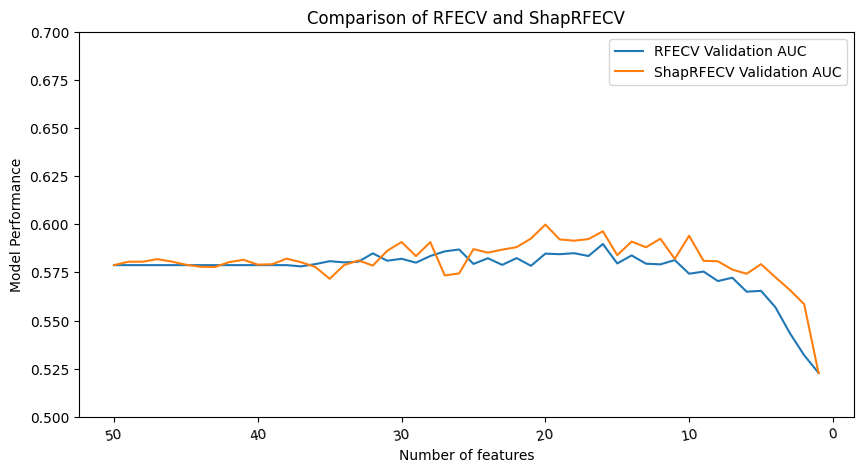

In [15]:
# Run RFECV and ShapRFECV with identical parameters.
rfe = RFECV(model, step=1, cv=20, scoring="roc_auc", n_jobs=3).fit(X_train, y_train)
shap_elimination = ShapRFECV(model=model, step=1, cv=20, scoring="roc_auc", n_jobs=3, random_state=0)
shap_report = shap_elimination.fit_compute(X_train, y_train)

# Construct a DataFrame to compare CV Validation AUC for different numbers of features.
validation_auc_df = pd.DataFrame(
    {
        "RFECV Validation AUC": list(reversed(rfe.cv_results_["mean_test_score"])),
        "ShapRFECV Validation AUC": shap_report["val_metric_mean"].values.tolist(),
    },
    index=shap_report["num_features"].values.tolist(),
)

# Plot the comparison of RFECV and ShapRFECV performances.
ax = validation_auc_df.plot(ylim=(0.5, 0.7), rot=10, title="Comparison of RFECV and ShapRFECV", figsize=(10, 5))
ax.set_ylabel("Model Performance")
ax.set_xlabel("Number of features")
ax.invert_xaxis()
plt.show()

The plot above illustrates the averaged CV Validation AUC for each RFE round in both ShapRFECV and RFECV. ShapRFECV achieves optimal performance with 16 features (highest mean validation metric), while RFECV peaks with 15 features.

Next, we compare the performance of models trained on:

- All 50 available features (baseline),
- 15 features selected by RFECV (final),
- 16 features selected by ShapRFECV (final),
- 15 features selected by ShapRFECV (baseline).

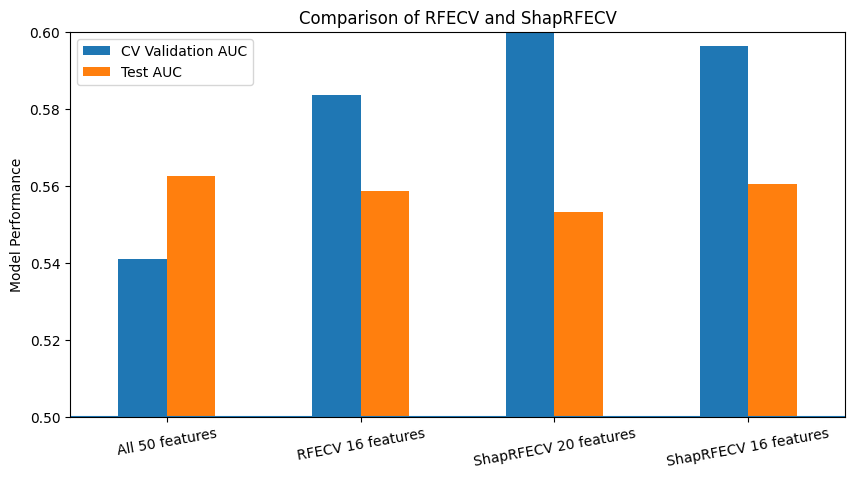

In [16]:
# Determine the number of features for SHAP and RFECV methods.
n_features_shap = len(shap_elimination.get_reduced_features_set("best"))  # Example: 16 features
n_features_rfecv = int(rfe.n_features_)  # Example: 15 features

# Calculate the AUC using all features.
test_auc_full = model.fit(X_train, y_train).score(X_test, y_test)
val_auc_full = np.mean(cross_val_score(model, X_train, y_train, cv=10))

# --- RFECV Optimal Feature Set ---
rfe_features_set = X_train.columns[rfe.support_]
test_auc_rfe = model.fit(X_train[rfe_features_set], y_train).score(X_test[rfe_features_set], y_test)
val_auc_rfe = rfe.cv_results_["mean_test_score"][n_features_rfecv]

# --- SHAP Optimal Feature Set ---
shap_feature_set = X_train.columns[shap_elimination.get_reduced_features_set(n_features_shap)]
test_auc_shap = model.fit(X_train[shap_feature_set], y_train).score(X_test[shap_feature_set], y_test)
val_auc_shap = shap_report[shap_report.num_features == n_features_shap]["val_metric_mean"].values[0]

# --- SHAP Feature Set with RFECV Number of Features ---
shap_feature_set_size_rfe = X_train.columns[shap_elimination.get_reduced_features_set(n_features_rfecv)]
test_auc_shap_size_rfe = model.fit(X_train[shap_feature_set_size_rfe], y_train).score(
    X_test[shap_feature_set_size_rfe], y_test
)
val_auc_shap_size_rfe = shap_report[shap_report.num_features == n_features_rfecv]["val_metric_mean"].values[0]

# --- Plotting Performance Comparison ---
variants = (
    "All 50 features",
    f"RFECV {n_features_rfecv} features",
    f"ShapRFECV {n_features_shap} features",
    f"ShapRFECV {n_features_rfecv} features",
)
results_test = [test_auc_full, test_auc_rfe, test_auc_shap, test_auc_shap_size_rfe]
results_val = [val_auc_full, val_auc_rfe, val_auc_shap, val_auc_shap_size_rfe]

performance_df = pd.DataFrame(
    {"CV Validation AUC": results_val, "Test AUC": results_test},
    index=variants,
)

ax = performance_df.plot.bar(ylim=(0.5, 0.6), rot=10, title="Comparison of RFECV and ShapRFECV", figsize=(10, 5))
plt.axhline(y=0.5)
ax.set_ylabel("Model Performance")
plt.show()

The plot demonstrates that ShapRFECV yields superior CV Validation and Test AUC compared to both RFECV and the full-feature baseline. It not only removes redundant features without compromising performance but may also enhance model accuracy.

In terms of computation time, ShapRFECV takes a bit longer than RFECV, mainly due to the additional overhead of calculating SHAP values.